# Chronos-2 — Individual Layer Benchmark

Layer-level benchmarks comparing each optimised kernel against its original counterpart in isolation.

| Kernel | Layer | Sweep | Fixed |
|---|---|---|---|
| **RoPE Fused** | `TimeSelfAttention` | Sequence length | batch = 4 |
| **BSR** | `GroupSelfAttention` | Batch size (N variates) | T = 64 |
| **Bucketed** | `GroupSelfAttention` | Batch size (N variates) | T = 64 |

Each kernel produces **one speedup graph**. BSR and Bucketed are evaluated under four uniform group structures:
- `g=1`  — univariate (`group_ids = arange(B)`, each sample its own group)
- `g=2`  — pairs (`group_ids = arange(B) // 2`, B/2 groups of 2)
- `g=4`  — quads (`group_ids = arange(B) // 4`, B/4 groups of 4)
- `g=16` — large groups (`group_ids = arange(B) // 16`, B/16 groups of 16)

No cross-kernel comparisons — see `chronos2_comprehensive_benchmark.ipynb` for that.


## 1. Imports & Config


In [31]:
GROUP_MODES       = ['g=1', 'g=2', 'g=4', 'g=16']   # uniform group-size cases

WARMUP = 5
ITERS  = 20

# ── Colours & markers — one per group mode ────────────────────────────────────
COLORS = {
    'baseline':   '#4C72B0',
    'rope_fused': '#DD8452',
    'bsr':        '#2ca02c',
    'bucketed':   '#9467bd',
    'g=1':        '#1f77b4',   # blue   — univariate
    'g=2':        '#d62728',   # red    — pairs
    'g=4':        '#9467bd',   # purple — quads
    'g=16':       '#2ca02c',   # green  — groups of 16
}
MARKERS = {
    'g=1':  'o',
    'g=2':  's',
    'g=4':  '^',
    'g=16': 'D',
}


## 2. Layer Construction Helpers

- **RoPE**: Builds a `TimeSelfAttention` baseline and a fused variant where the inner `MHA` is swapped for `RoPEFusedMHA`. Weights are shared via `load_state_dict`.
- **BSR**: Builds a `GroupSelfAttention` baseline and a BSR variant where the inner `MHA` is replaced by `SparseGroupMHA(group_ids=...)`. Rebuilt per batch size.
- **Bucketed**: Builds a `GroupSelfAttention` baseline and a bucketed variant using `GroupAwareMHA(partition=...)`. Rebuilt per batch size.


In [25]:
from chop.models.chronos2.layers import GroupSelfAttention, TimeSelfAttention
from chop.models.chronos2.optimized_layers import (
    GroupAwareMHA,
    GroupPartition,
    KernelVariant,
    RoPEFusedMHA,
)
from chop.models.chronos2.sparse_group_mha import SparseGroupMHA
from chop.models.chronos2.triton_rope_attn import is_triton_available as is_rope_triton_available
from chop.models.chronos2.triton_grouped_attn import is_triton_available as is_grouped_triton_available

print(f'Triton RoPE      : {"available ✓" if is_rope_triton_available() else "NOT available"}')
print(f'Triton group-attn: {"available ✓" if is_grouped_triton_available() else "NOT available"}')


# ── RoPE ─────────────────────────────────────────────────────────────────────
def build_rope_layers():
    """Return (baseline_tsa, fused_tsa) with shared weights."""
    baseline = TimeSelfAttention(LAYER_CFG).to(DEVICE, dtype=DTYPE).eval()
    fused    = TimeSelfAttention(LAYER_CFG).to(DEVICE, dtype=DTYPE).eval()
    fused.load_state_dict(baseline.state_dict())

    fused_mha = RoPEFusedMHA(config=baseline.self_attention.config)
    fused_mha.load_state_dict(baseline.self_attention.state_dict(), strict=False)
    fused_mha.to(DEVICE, dtype=DTYPE).eval()
    fused.self_attention = fused_mha

    return baseline, fused


# ── GroupSelfAttention base ───────────────────────────────────────────────────
def build_base_gsa():
    """A fresh GroupSelfAttention baseline layer."""
    return GroupSelfAttention(LAYER_CFG).to(DEVICE, dtype=DTYPE).eval()


# ── BSR (per batch size) ──────────────────────────────────────────────────────
def build_bsr_layer(base_gsa: GroupSelfAttention, group_ids: torch.Tensor):
    """Swap base_gsa inner MHA for SparseGroupMHA with the given group_ids."""
    group_ids_dev = group_ids.to(DEVICE)
    sparse_mha = SparseGroupMHA(LAYER_CFG, group_ids=group_ids_dev).to(DEVICE, dtype=DTYPE).eval()
    sparse_mha.load_state_dict(base_gsa.self_attention.state_dict(), strict=False)

    bsr_gsa = GroupSelfAttention(LAYER_CFG).to(DEVICE, dtype=DTYPE).eval()
    bsr_gsa.load_state_dict(base_gsa.state_dict())
    bsr_gsa.self_attention = sparse_mha
    return bsr_gsa


# ── Bucketed (per batch size) ─────────────────────────────────────────────────
def build_bucketed_layer(base_gsa: GroupSelfAttention, group_ids_cpu: torch.Tensor):
    """Swap base_gsa inner MHA for GroupAwareMHA with the given group partition."""
    partition = GroupPartition.from_group_ids(group_ids_cpu)
    aware_mha = GroupAwareMHA(LAYER_CFG, partition=partition)
    aware_mha.load_state_dict(base_gsa.self_attention.state_dict(), strict=True)
    aware_mha.to(DEVICE, dtype=DTYPE).eval()

    bucketed_gsa = GroupSelfAttention(LAYER_CFG).to(DEVICE, dtype=DTYPE).eval()
    bucketed_gsa.load_state_dict(base_gsa.state_dict())
    bucketed_gsa.self_attention = aware_mha
    return bucketed_gsa


print('Layer construction helpers ready.')


Triton RoPE      : available ✓
Triton group-attn: available ✓
Layer construction helpers ready.


## 3. Benchmark Utilities


In [32]:
def benchmark_fn(fn, warmup: int = WARMUP, iters: int = ITERS) -> float:
    """Return median latency in milliseconds."""
    use_cuda = DEVICE.type == 'cuda'
    if use_cuda:
        s_ev = torch.cuda.Event(enable_timing=True)
        e_ev = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(warmup):
            fn()
        if use_cuda:
            torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(iters):
            if use_cuda:
                s_ev.record()
                fn()
                e_ev.record()
                torch.cuda.synchronize()
                times.append(s_ev.elapsed_time(e_ev))
            else:
                t0 = _time.perf_counter()
                fn()
                times.append((_time.perf_counter() - t0) * 1e3)
    return statistics.median(times)


def make_gids(mode: str, bs: int) -> torch.Tensor:
    """Create group_ids on CPU for a given group mode and batch size.

    mode is 'g=N': uniform groups of size N, i.e. torch.arange(B) // N.
      g=1 → univariate (each sample its own group)
      g=2 → pairs
      g=4 → quads
    """
    g = int(mode.split('=')[1])
    return torch.arange(bs, dtype=torch.long) // g


def make_group_mask(group_ids: torch.Tensor, T: int) -> torch.Tensor:
    """Build the additive attention mask for GroupSelfAttention.

    Returns shape: (T, 1, B, B)  on DEVICE.
    """
    gids = group_ids.to(DEVICE)
    B = gids.shape[0]
    group_mask = (gids[:, None] == gids[None, :]).float()
    time_mask  = torch.ones(B, T, device=DEVICE, dtype=DTYPE)
    gtm = torch.einsum('qb,bt->qbt', group_mask, time_mask)
    gtm = gtm.permute(2, 0, 1).unsqueeze(1)
    return ((1.0 - gtm) * torch.finfo(DTYPE).min).to(DTYPE)


def make_tsa_inputs(B: int, S: int):
    """Inputs for TimeSelfAttention: (hidden_states, mask, position_ids)."""
    hidden = torch.randn(B, S, LAYER_CFG.d_model, device=DEVICE, dtype=DTYPE)
    mask   = torch.zeros(B, 1, S, S, device=DEVICE, dtype=DTYPE)
    pos    = torch.arange(S, device=DEVICE, dtype=torch.long).unsqueeze(0).expand(B, -1)
    return hidden, mask, pos


print('Benchmark utilities ready.')


Benchmark utilities ready.


## 4. RoPE Attention — Sequence Length Sweep

Compares `TimeSelfAttention` (baseline sdpa) against the fused `RoPEFusedMHA` variant.  
Fixed batch = 4, sweep sequence length ∈ [256, 512, 1024, 2048, 4096, 8192].


In [27]:
rope_results = {'baseline': [], 'rope_fused': []}

baseline_tsa, fused_tsa = build_rope_layers()

print(f'RoPE sequence sweep  (batch={FIXED_BATCH_ROPE})')
print(f"{'SeqLen':>7} | {'baseline (ms)':>14} | {'rope_fused (ms)':>16} | {'speedup':>8}")
print('-' * 58)

for seq in SEQ_LENS_ROPE:
    hidden, mask, pos = make_tsa_inputs(FIXED_BATCH_ROPE, seq)

    def _baseline(h=hidden, m=mask, p=pos):
        baseline_tsa(h, m, position_ids=p)

    def _fused(h=hidden, m=mask, p=pos):
        fused_tsa(h, m, position_ids=p)

    t_base  = benchmark_fn(_baseline)
    t_fused = benchmark_fn(_fused)
    speedup = t_base / t_fused

    rope_results['baseline'].append(t_base)
    rope_results['rope_fused'].append(t_fused)

    print(f'{seq:>7} | {t_base:>13.3f}ms | {t_fused:>15.3f}ms | {speedup:>7.2f}×')

del baseline_tsa, fused_tsa
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


RoPE sequence sweep  (batch=4)
 SeqLen |  baseline (ms) |  rope_fused (ms) |  speedup
----------------------------------------------------------
     16 |         0.492ms |           0.339ms |    1.45×
     32 |         0.521ms |           0.346ms |    1.51×
     64 |         0.529ms |           0.324ms |    1.63×
    128 |         0.479ms |           0.407ms |    1.18×
    256 |         0.533ms |           0.371ms |    1.44×
    512 |         0.668ms |           0.429ms |    1.56×
   1024 |         1.227ms |           0.773ms |    1.59×
   2048 |         3.309ms |           1.949ms |    1.70×
   4096 |        11.098ms |           5.597ms |    1.98×
   8192 |        39.084ms |          18.771ms |    2.08×


## 5. BSR — Batch Size Sweep

Compares `GroupSelfAttention` (baseline) against the `SparseGroupMHA` (BSR) replacement.  
Fixed T = 64, sweep batch size ∈ [4, 8, 16, 32, 64, 128, 256, 512].

Three group structures are tested: `g=1` (univariate), `g=2` (pairs), `g=4` (quads).  
`SparseGroupMHA` is rebuilt for each batch size with the appropriate `group_ids`.


In [33]:
bsr_results = {mode: {'baseline': [], 'bsr': []} for mode in GROUP_MODES}

for mode in GROUP_MODES:
    print(f'\nBSR batch sweep  (T={FIXED_T_GROUP}, {mode})')
    print(f"{'Batch':>6} | {'baseline (ms)':>14} | {'bsr (ms)':>10} | {'speedup':>8}")
    print('-' * 50)

    for bs in BATCH_SIZES_GROUP:
        gids_cpu = make_gids(mode, bs)
        gids_dev = gids_cpu.to(DEVICE)

        hidden = torch.randn(bs, FIXED_T_GROUP, LAYER_CFG.d_model, device=DEVICE, dtype=DTYPE)
        mask   = make_group_mask(gids_cpu, FIXED_T_GROUP)

        base_gsa = build_base_gsa()
        bsr_gsa  = build_bsr_layer(base_gsa, gids_dev)

        def _base(h=hidden, m=mask):
            base_gsa(h, m)

        def _bsr(h=hidden, m=mask):
            bsr_gsa(h, m)

        t_base = benchmark_fn(_base)
        t_bsr  = benchmark_fn(_bsr)
        speedup = t_base / t_bsr

        bsr_results[mode]['baseline'].append(t_base)
        bsr_results[mode]['bsr'].append(t_bsr)

        print(f'{bs:>6} | {t_base:>13.3f}ms | {t_bsr:>9.3f}ms | {speedup:>7.2f}×')

        del base_gsa, bsr_gsa
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()



BSR batch sweep  (T=64, g=1)
 Batch |  baseline (ms) |   bsr (ms) |  speedup
--------------------------------------------------
     4 |         0.791ms |     0.847ms |    0.93×
     8 |         0.551ms |     0.571ms |    0.97×
    16 |         1.277ms |     1.421ms |    0.90×
    32 |         0.545ms |     0.500ms |    1.09×
    64 |         3.032ms |     5.208ms |    0.58×
   128 |         1.490ms |     1.175ms |    1.27×
   256 |         3.998ms |     2.165ms |    1.85×
   512 |        12.009ms |     4.617ms |    2.60×

BSR batch sweep  (T=64, g=2)
 Batch |  baseline (ms) |   bsr (ms) |  speedup
--------------------------------------------------
     4 |         1.025ms |     1.112ms |    0.92×
     8 |         0.442ms |     0.493ms |    0.90×
    16 |         0.971ms |     0.929ms |    1.05×
    32 |         0.836ms |     0.777ms |    1.08×
    64 |         0.663ms |     0.600ms |    1.11×
   128 |         1.414ms |     1.137ms |    1.24×
   256 |         4.125ms |     2.214ms |  

## 6. Bucketed — Batch Size Sweep

Compares `GroupSelfAttention` (baseline) against the `GroupAwareMHA` (Bucketed) replacement.  
Fixed T = 64, sweep batch size ∈ [4, 8, 16, 32, 64, 128, 256, 512].

Three group structures are tested: `g=1` (univariate), `g=2` (pairs), `g=4` (quads).  
`GroupAwareMHA` is rebuilt per batch size because `GroupPartition` (and precomputed Triton buffers) depends on the batch group structure.


In [34]:
bucketed_results = {mode: {'baseline': [], 'bucketed': []} for mode in GROUP_MODES}

for mode in GROUP_MODES:
    print(f'\nBucketed batch sweep  (T={FIXED_T_GROUP}, {mode})')
    print(f"{'Batch':>6} | {'baseline (ms)':>14} | {'bucketed (ms)':>14} | {'speedup':>8}")
    print('-' * 54)

    for bs in BATCH_SIZES_GROUP:
        gids_cpu = make_gids(mode, bs)

        hidden = torch.randn(bs, FIXED_T_GROUP, LAYER_CFG.d_model, device=DEVICE, dtype=DTYPE)
        mask   = make_group_mask(gids_cpu, FIXED_T_GROUP)

        base_gsa     = build_base_gsa()
        bucketed_gsa = build_bucketed_layer(base_gsa, gids_cpu)

        def _base(h=hidden, m=mask):
            base_gsa(h, m)

        def _bucketed(h=hidden, m=mask):
            bucketed_gsa(h, m)

        t_base     = benchmark_fn(_base)
        t_bucketed = benchmark_fn(_bucketed)
        speedup    = t_base / t_bucketed

        bucketed_results[mode]['baseline'].append(t_base)
        bucketed_results[mode]['bucketed'].append(t_bucketed)

        print(f'{bs:>6} | {t_base:>13.3f}ms | {t_bucketed:>13.3f}ms | {speedup:>7.2f}×')

        del base_gsa, bucketed_gsa
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()



Bucketed batch sweep  (T=64, g=1)
 Batch |  baseline (ms) |  bucketed (ms) |  speedup
------------------------------------------------------
     4 |         0.441ms |         0.357ms |    1.24×
     8 |         0.940ms |         0.364ms |    2.58×
    16 |         0.431ms |         0.347ms |    1.24×
    32 |         0.432ms |         0.431ms |    1.00×
    64 |         0.721ms |         0.603ms |    1.20×
   128 |         1.702ms |         1.190ms |    1.43×
   256 |         4.201ms |         2.224ms |    1.89×
   512 |        12.005ms |         4.524ms |    2.65×

Bucketed batch sweep  (T=64, g=2)
 Batch |  baseline (ms) |  bucketed (ms) |  speedup
------------------------------------------------------
     4 |         0.706ms |         0.457ms |    1.55×
     8 |         0.424ms |         0.405ms |    1.05×
    16 |         0.419ms |         0.391ms |    1.07×
    32 |         0.442ms |         0.411ms |    1.07×
    64 |         0.870ms |         0.645ms |    1.35×
   128 |      

## 7. Visualization — Speedup Graphs

Three graphs side by side, one per kernel.  
Y-axis: speedup vs baseline (×) with dynamic lower bound.  
X-axis: sequence length (RoPE) or batch size (BSR, Bucketed) on log₂ scale.


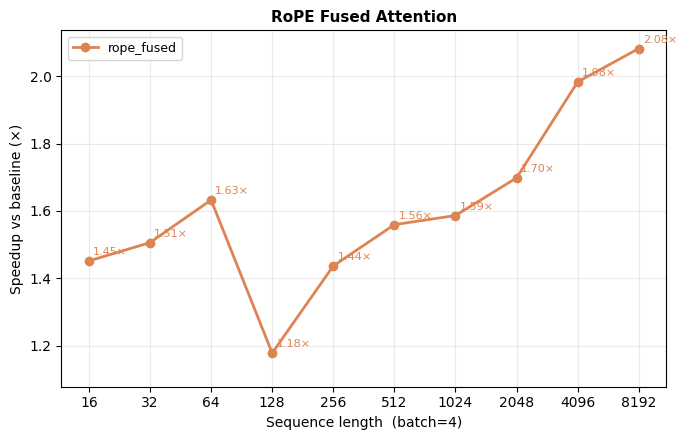

Saved → artifacts/layer_benchmark/layer_speedup_rope.png


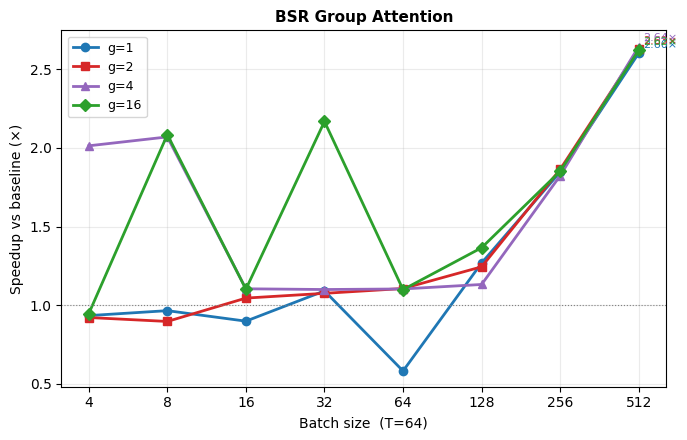

Saved → artifacts/layer_benchmark/layer_speedup_bsr.png


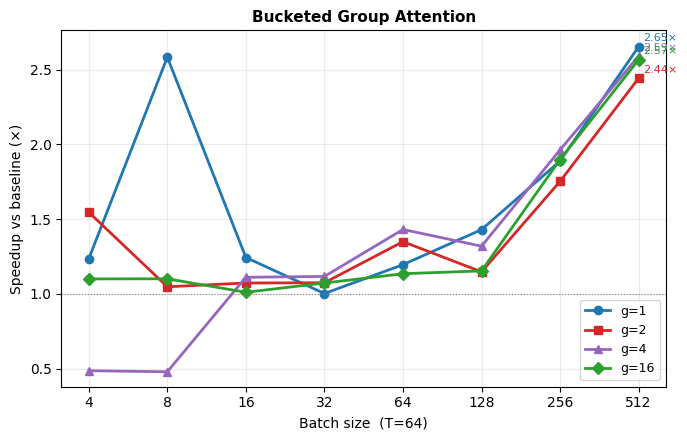

Saved → artifacts/layer_benchmark/layer_speedup_bucketed.png


In [ ]:
def _setup_ax(ax, x_vals, x_label, ylim, title):
    ax.axhline(1.0, color='grey', lw=0.8, ls=':')
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel('Speedup vs baseline (×)', fontsize=10)
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xticks(x_vals)
    ax.set_ylim(bottom=ylim)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')


# ── Figure 1: RoPE — seq sweep ───────────────────────────────────────────────
base_arr  = np.array(rope_results['baseline'])
fused_arr = np.array(rope_results['rope_fused'])
su_rope   = base_arr / fused_arr

fig1, ax_rope = plt.subplots(figsize=(7, 4.5))
ax_rope.plot(SEQ_LENS_ROPE, su_rope, marker='o', ls='-',
             color=COLORS['rope_fused'], lw=2.0, label='rope_fused')

_setup_ax(ax_rope, SEQ_LENS_ROPE,
          f'Sequence length  (batch={FIXED_BATCH_ROPE})',
          min(su_rope) - 0.1, 'RoPE Fused Attention')

fig1.tight_layout()
save1 = OUTPUT_DIR / 'layer_speedup_rope.png'
fig1.savefig(save1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save1}')


# ── Figure 2: BSR — batch sweep ──────────────────────────────────────────────
fig2, ax_bsr = plt.subplots(figsize=(7, 4.5))
all_su_bsr = []
for mode in GROUP_MODES:
    base_arr = np.array(bsr_results[mode]['baseline'])
    bsr_arr  = np.array(bsr_results[mode]['bsr'])
    su       = base_arr / bsr_arr
    all_su_bsr.append(su)
    ax_bsr.plot(BATCH_SIZES_GROUP, su, marker=MARKERS[mode], ls='-',
                color=COLORS[mode], lw=2.0, label=mode)
    ax_bsr.annotate(f'{su[-1]:.2f}×', xy=(BATCH_SIZES_GROUP[-1], su[-1]),
                    xytext=(3, 4), textcoords='offset points',
                    fontsize=8, color=COLORS[mode])

_setup_ax(ax_bsr, BATCH_SIZES_GROUP,
          f'Batch size  (T={FIXED_T_GROUP})',
          min(np.concatenate(all_su_bsr)) - 0.1, 'BSR Group Attention')

fig2.tight_layout()
save2 = OUTPUT_DIR / 'layer_speedup_bsr.png'
fig2.savefig(save2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save2}')


# ── Figure 3: Bucketed — batch sweep ─────────────────────────────────────────
fig3, ax_buck = plt.subplots(figsize=(7, 4.5))
all_su_buck = []
for mode in GROUP_MODES:
    base_arr = np.array(bucketed_results[mode]['baseline'])
    buck_arr = np.array(bucketed_results[mode]['bucketed'])
    su       = base_arr / buck_arr
    all_su_buck.append(su)
    ax_buck.plot(BATCH_SIZES_GROUP, su, marker=MARKERS[mode], ls='-',
                 color=COLORS[mode], lw=2.0, label=mode)
    ax_buck.annotate(f'{su[-1]:.2f}×', xy=(BATCH_SIZES_GROUP[-1], su[-1]),
                     xytext=(3, 4), textcoords='offset points',
                     fontsize=8, color=COLORS[mode])

_setup_ax(ax_buck, BATCH_SIZES_GROUP,
          f'Batch size  (T={FIXED_T_GROUP})',
          min(np.concatenate(all_su_buck)) - 0.1, 'Bucketed Group Attention')

fig3.tight_layout()
save3 = OUTPUT_DIR / 'layer_speedup_bucketed.png'
fig3.savefig(save3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {save3}')
